In [4]:
import torch
import matplotlib.pyplot as plt
import numpy as np 

Ключи файла:
 ['pred_zts', 'true_zts', 'pert_zts', 'trajectory_mae', 'int_rel_err_pred_true', 'int_abs_err_pred_true', 'int_rel_err_pert_true', 'int_abs_err_pert_true', 'int_pred_true_energy', 'int_true_true_energy', 'int_pert_true_energy']


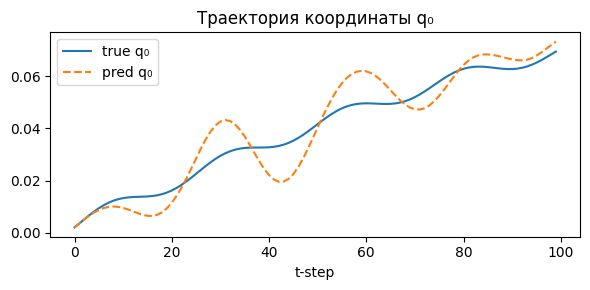

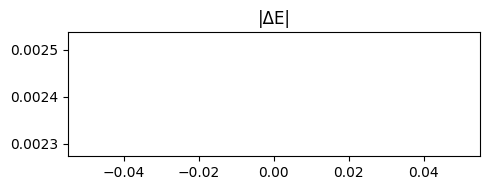

trajectory_mae              : 0.1294
int_rel_err_pred_true       : -7.122
int_abs_err_pred_true       : -0.4721
int_rel_err_pert_true       : -21.11
int_abs_err_pert_true       : -14.45


In [5]:

# 1. путь к файлу (замените на свой)
pt_file = "wandb/latest-run/files/test_log.pt"   # или просто "test_log.pt"

# 2. загрузка
log = torch.load(pt_file, map_location="cpu", weights_only=False)
print("Ключи файла:\n", list(log.keys()))

# ─── 3. графики ────────────────────────────────────────────────────────────
# 3.1 первая траектория: истинная vs предсказанная
true_zts = log["true_zts"][0]    # (T, 2, n_dof, d)
pred_zts = log["pred_zts"][0]

plt.figure(figsize=(6, 3))
plt.plot(true_zts[:, 0, 0, 0], label="true q₀")
plt.plot(pred_zts[:, 0, 0, 0], "--", label="pred q₀")
plt.title("Траектория координаты q₀")
plt.xlabel("t-step"); plt.legend(); plt.tight_layout(); plt.show()

# 3.2 усреднённая ошибка энергии (если сохранили)
if "int_pred_true_energy" in log:
    # вариант 1 – через numpy.abs
    dE = np.abs(log["int_pred_true_energy"] - log["int_true_true_energy"])

    # или вариант 2 – привести к тензору
    # dE = torch.tensor(log["int_pred_true_energy"]) - torch.tensor(log["int_true_true_energy"])
    # dE = dE.abs()

    plt.figure(figsize=(5, 2))
    plt.plot([dE])          # это всего лишь одна точка; можно просто вывести текстом
    plt.title("|ΔE|")
    plt.tight_layout()
    plt.show()
# 3.3 метрики
for k in ("trajectory_mae",
          "int_rel_err_pred_true", "int_abs_err_pred_true",
          "int_rel_err_pert_true", "int_abs_err_pert_true"):
    if k in log:
        print(f"{k:28s}: {log[k]:.4g}")
